In [73]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
import math
from scipy import optimize

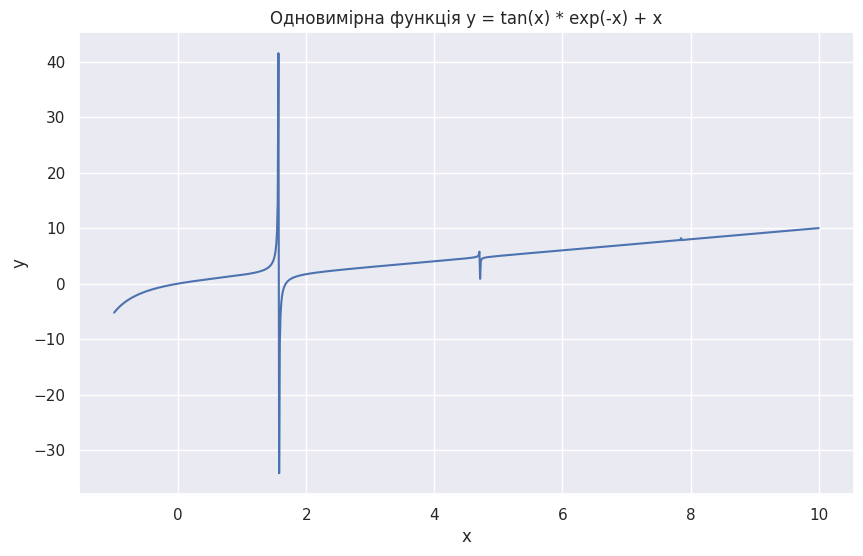

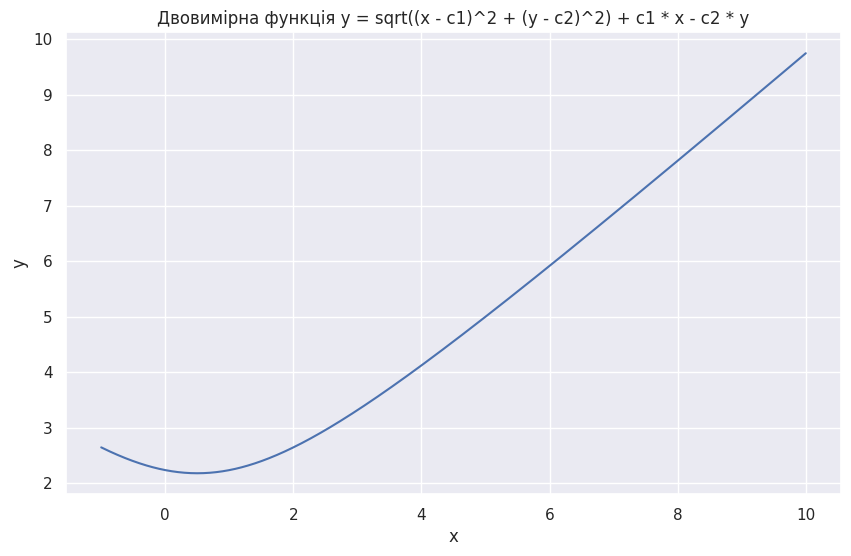

In [74]:
x = np.linspace(-1.0, 10.0, 1000)
y = np.tan(x) * np.exp(-x) + x

sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 6))
plt.plot(x, y)
plt.title('Одновимірна функція y = tan(x) * exp(-x) + x')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

def f(x, y, c1, c2):
    return np.sqrt(((x - c1) ** 2 + (y - c2) ** 2) + c1 * x - c2 * y)

x_2 = np.linspace(-1.0, 10.0, 1000)
y_2 = f(x_2, 0, 1, 2)
sns.set_theme(style="darkgrid")

plt.figure(figsize=(10, 6))
plt.plot(x_2, y_2)
plt.title('Двовимірна функція y = sqrt((x - c1)^2 + (y - c2)^2) + c1 * x - c2 * y')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()



Мінімум функції знаходиться приблизно в точці x = -1.000000, y = -5.233468
Максимум функції знаходиться приблизно в точці x = -0.000000, y = -0.000001


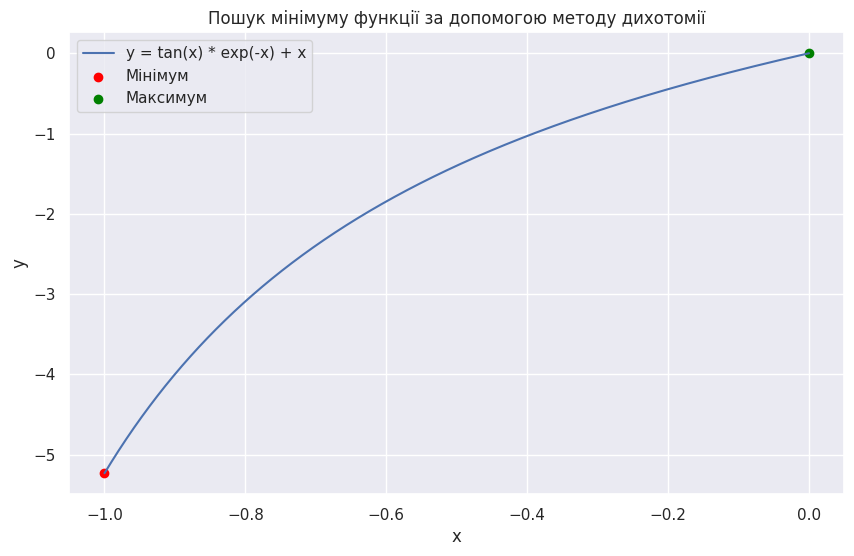

In [75]:
def func(x):
    return np.tan(x) * np.exp(-x) + x

def dichotomy_min(func, a, b, eps=1e-6, max_iter=1000):
    if a >= b:
        raise ValueError("Початок інтервалу a має бути меншим за кінець b.")
    
    for _ in range(max_iter):
        x1 = a + (b - a) / 3
        x2 = a + 2 * (b - a) / 3
        
        f_x1 = func(x1)
        f_x2 = func(x2)
        
        if f_x1 < f_x2:
            b = x2  
        else:
            a = x1  
        
        if abs(b - a) < eps:
            break
    else:
        print("Досягнуто максимальну кількість ітерацій.")
    
    return (a + b) / 2

def dichotomy_max(func, a, b, eps=1e-6, max_iter=1000):
    if a >= b:
        raise ValueError("Початок інтервалу a має бути меншим за кінець b.")
    
    for _ in range(max_iter):
        x1 = a + (b - a) / 3
        x2 = a + 2 * (b - a) / 3
        
        f_x1 = func(x1)
        f_x2 = func(x2)
        
        if f_x1 > f_x2:
            b = x2  
        else:
            a = x1  
        
        if abs(b - a) < eps:
            break
    else:
        print("Досягнуто максимальну кількість ітерацій.")
    
    return (a + b) / 2

a = -1.0  
b = 0.0   
eps = 1e-6  

x_min = dichotomy_min(func, a, b, eps)
y_min = func(x_min)

x_max = dichotomy_max(func, a, b, eps)
y_max = func(x_max)

print(f"Мінімум функції знаходиться приблизно в точці x = {x_min:.6f}, y = {y_min:.6f}")
print(f"Максимум функції знаходиться приблизно в точці x = {x_max:.6f}, y = {y_max:.6f}")

x = np.linspace(-1.0, 0.0, 1000)
y = func(x)

sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='y = tan(x) * exp(-x) + x')
plt.scatter(x_min, y_min, color='red', label='Мінімум')
plt.scatter(x_max, y_max, color='green', label='Максимум')
plt.title('Пошук мінімуму функції за допомогою методу дихотомії')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Мінімум функції знаходиться приблизно в точці x = -1.000000, y = -5.233473
Максимум функції знаходиться приблизно в точці x = 0.000000, y = 0.000000


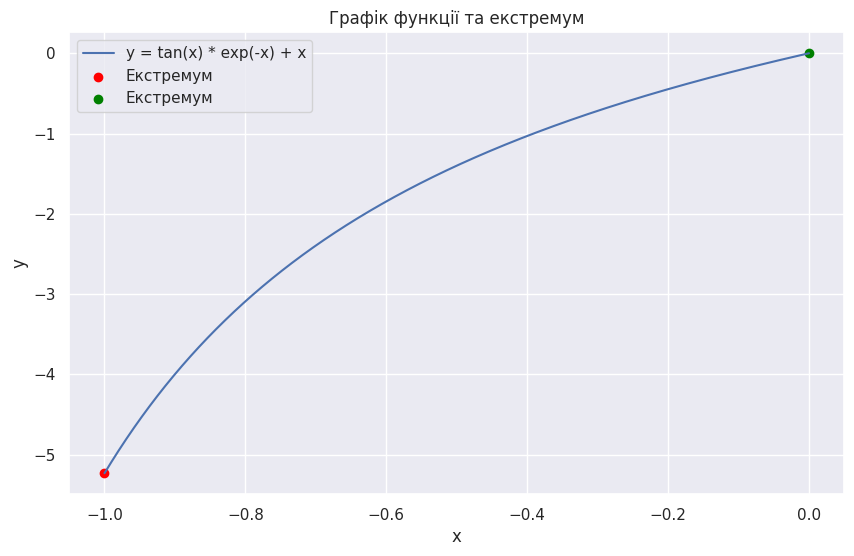

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def func(x):
    if x < -1 or x > 0:
        return np.inf 
    return np.tan(x) * np.exp(-x) + x

def func2(x):
    return np.tan(x) * np.exp(-x) + x

def gradient(x):
    if x < -1:
        return -1  
    elif x > 0:
        return 1   
    else:
        cos_x = np.cos(x)
        exp_neg_x = np.exp(-x)
        return (exp_neg_x / cos_x**2) - (np.tan(x) * exp_neg_x) + 1

def fast_descent_min(f, grad, x0, h=0.01, epsilon=1e-6, max_iter=1000):
    x = x0
    g = grad(x)
    i = np.sign(g)

    for _ in range(max_iter):
        x_new = x - h * g
        if x_new < -1:
            x_new = -1
        elif x_new > 0:
            x_new = 0
        g_new = grad(x_new)

        if np.isnan(g_new) or np.isinf(g_new):
            print("Зустріно nan або inf. Зупинка.")
            return x_new

        if abs(g_new) < epsilon or (x_new <= -1 and g_new > 0) or (x_new >= 0 and g_new < 0):
            return x_new

        i1 = np.sign(g_new)
        if i1 != i:
            h = h / 2
        else:
            h = 1.6 * h 

        x = x_new
        g = g_new
        i = i1

    print("Досягнуто максимальну кількість ітерацій.")
    return x

def fast_descent_max(f, grad, x0, h=0.01, epsilon=1e-6, max_iter=1000):
    x = x0
    g = grad(x)
    i = np.sign(g)

    for _ in range(max_iter):
        x_new = x + h * g
        if x_new < -1:
            x_new = -1
        elif x_new > 0:
            x_new = 0
        g_new = grad(x_new)

        if np.isnan(g_new) or np.isinf(g_new):
            print("Зустріно nan або inf. Зупинка.")
            return x_new

        if abs(g_new) < epsilon or (x_new <= -1 and g_new < 0) or (x_new >= 0 and g_new > 0):
            return x_new

        i1 = np.sign(g_new)
        if i1 != i:
            h = h / 2
        else:
            h = 1.6 * h 

        x = x_new
        g = g_new
        i = i1

    print("Досягнуто максимальну кількість ітерацій.")
    return x

x0 = -0.5  
x_min = fast_descent_min(func, gradient, x0)
y_min = func(x_min)
print(f"Мінімум функції знаходиться приблизно в точці x = {x_min:.6f}, y = {y_min:.6f}")

x0 = -0.5
x_max = fast_descent_max(func, gradient, x0)
y_max = func(x_max)
print(f"Максимум функції знаходиться приблизно в точці x = {x_max:.6f}, y = {y_max:.6f}")

x_values = np.linspace(-1, 0, 1000)
y_values = func2(x_values)

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label='y = tan(x) * exp(-x) + x')
plt.scatter(x_min, y_min, color='red', label='Екстремум')
plt.scatter(x_max, y_max, color='green', label='Екстремум')
plt.title('Графік функції та екстремум')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

In [78]:

def objective_function(x, y, c1=1, c2=1):
    expr = ((x - c1) ** 2 + (y - c2) ** 2) + c1 * x - c2 * y
    if np.isscalar(expr):
        return np.sqrt(max(expr, 0))
    else:
        return np.sqrt(np.maximum(expr, 0))

def gradient(x, y, c1=1, c2=1):
    expr = ((x - c1) ** 2 + (y - c2) ** 2) + c1 * x - c2 * y
    
    if np.isscalar(expr):
        if expr <= 0:
            return 0, 0
        sqrt_expr = np.sqrt(expr)
    else:
        mask = expr <= 0
        sqrt_expr = np.sqrt(np.maximum(expr, 1e-10))  
        
    df_dx = (2 * (x - c1) + c1) / (2 * sqrt_expr)
    df_dy = (2 * (y - c2) - c2) / (2 * sqrt_expr)
    
    if np.isscalar(df_dx) and np.isscalar(df_dy):
        if np.isnan(df_dx) or np.isnan(df_dy):
            return 0, 0
    else:
        df_dx = np.nan_to_num(df_dx)
        df_dy = np.nan_to_num(df_dy)
    
    return df_dx, df_dy

def gradient_descent(start_x, start_y, learning_rate=0.01, max_iterations=1000, eps=1e-6, c1=1, c2=1):
    x, y = start_x, start_y
    path = [(x, y)]
    values = [objective_function(x, y, c1, c2)]
    
    consecutive_nan_count = 0
    consecutive_no_improvement = 0
    
    for i in range(max_iterations):
        dx, dy = gradient(x, y, c1, c2)
        
        if np.isnan(dx) or np.isnan(dy) or (dx == 0 and dy == 0):
            consecutive_nan_count += 1
            if consecutive_nan_count > 5:  
                print(f"NaN gradient at coordinates ({x}, {y})")
                break
            
            dx = np.random.normal(0, 0.1)
            dy = np.random.normal(0, 0.1)
        else:
            consecutive_nan_count = 0
        
        gradient_norm = np.sqrt(dx**2 + dy**2)
        if gradient_norm > 1.0:  
            dx = dx / gradient_norm
            dy = dy / gradient_norm
        
        new_x = x - learning_rate * dx
        new_y = y - learning_rate * dy
        
        new_value = objective_function(new_x, new_y, c1, c2)
        
        if np.isnan(new_value) or new_value > values[-1]:
            learning_rate *= 0.5
            consecutive_no_improvement += 1
            
            if consecutive_no_improvement > 10:
                break
                
            if learning_rate < 1e-10:
                break
                
            continue  
        else:
            consecutive_no_improvement = 0
        
        if abs(new_value - values[-1]) < eps:
            if i > 5 and abs(new_value - values[-5]) < eps:
                break
        
        x, y = new_x, new_y
        path.append((x, y))
        values.append(new_value)
        
        if i % 10 == 0 and consecutive_no_improvement == 0:
            learning_rate *= 1.1
    
    return x, y, path

c1 = 1 , c2 = 1
Початок (-4, -4): Мінімум функції знаходиться приблизно в точці (0.0946, 0.9449)
Початок (4, 4): Мінімум функції знаходиться приблизно в точці (1.0024, 1.8703)
Початок (4, -4): Мінімум функції знаходиться приблизно в точці (0.8779, 0.9964)
Початок (-4, 4): Мінімум функції знаходиться приблизно в точці (-0.0677, 1.8205)
Початок (0, 0): Мінімум функції знаходиться приблизно в точці (0.2910, 0.8680)


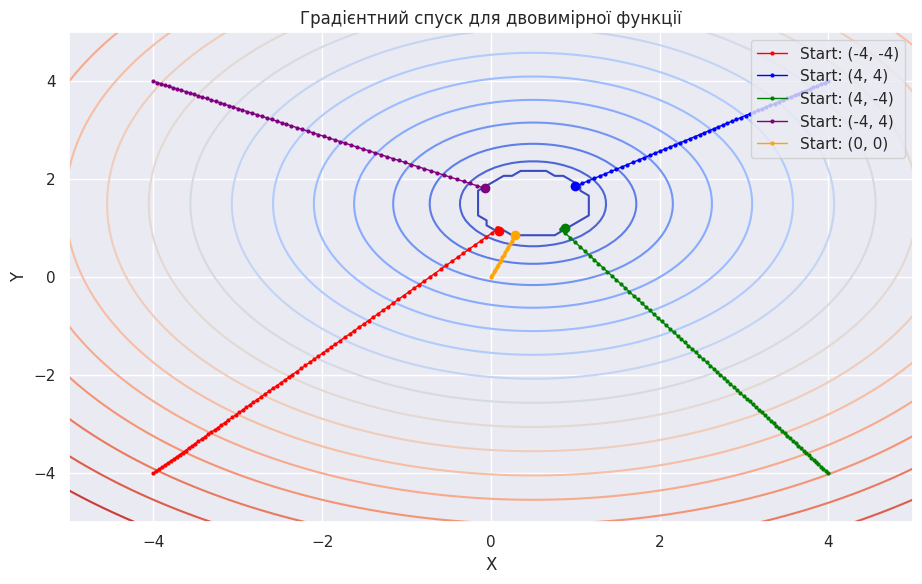

In [85]:
def plot_function_and_path(c1=1, c2=1):
    x = np.linspace(-5, 5, 100)
    y = np.linspace(-5, 5, 100)
    X, Y = np.meshgrid(x, y)
    
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = objective_function(X[i, j], Y[i, j], c1, c2)
    
    fig = plt.figure(figsize=(18, 6))
    
    start_points = [(-4, -4), (4, 4), (4, -4), (-4, 4), (0, 0)]
    colors = ['red', 'blue', 'green', 'purple', 'orange']
    
    ax2 = fig.add_subplot(122)
    contour = ax2.contour(X, Y, Z, 20, cmap=cm.coolwarm)
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_title('Градієнтний спуск для двовимірної функції')
    
    results = []
    for i, (start_x, start_y) in enumerate(start_points):
        min_x, min_y, path = gradient_descent(
            start_x, start_y, 
            learning_rate=0.05,  
            max_iterations=2000, 
            eps=1e-8,  
            c1=c1, c2=c2
        )
        
        if not (np.isnan(min_x) or np.isnan(min_y)):
            results.append((min_x, min_y))
        else:
            results.append((start_x, start_y, "Failed to converge"))
        
        path_x = [p[0] for p in path]
        path_y = [p[1] for p in path]
        
        ax2.plot(path_x, path_y, 'o-', color=colors[i], linewidth=1, markersize=2, 
                 label=f'Start: ({start_x}, {start_y})')
        
        ax2.plot(min_x, min_y, 'o', color=colors[i], markersize=6)
        
    plt.legend(loc='upper right')
    plt.tight_layout()
    
    for i, (min_x, min_y) in enumerate(results):
        print(f"Початок {start_points[i]}: Мінімум функції знаходиться приблизно в точці ({min_x:.4f}, {min_y:.4f})")
    
    return plt

c1, c2 = 1, 1
    
print("c1 =", c1, ", c2 =", c2)
    
plt_gd = plot_function_and_path(c1, c2)
fig_gd = plt.gcf()

c1 = 1 , c2 = 1
Власна функція
Початок (-4, -4): Мінімум функції знаходиться приблизно в точці (0.1038, 1.0163)
Початок (4, 4): Мінімум функції знаходиться приблизно в точці (1.0078, 1.8727)
Початок (4, -4): Мінімум функції знаходиться приблизно в точці (0.7946, 0.9826)
Початок (-4, 4): Мінімум функції знаходиться приблизно в точці (-0.0809, 1.7845)
Початок (0, 0): Мінімум функції знаходиться приблизно в точці (0.2930, 0.8484)

Scipy функції
Our GD:
Початок (-4, -4): Мінімум функції знаходиться приблизно в точці (0.0686, 1.0079)
Початок (4, 4): Мінімум функції знаходиться приблизно в точці (1.0271, 1.8433)
Початок (4, -4): Мінімум функції знаходиться приблизно в точці (0.8636, 0.9988)
Початок (-4, 4): Мінімум функції знаходиться приблизно в точці (-0.081, 1.8029)
Початок (0, 0): Мінімум функції знаходиться приблизно в точці (0.2894, 0.8572)
BFGS:
Початок (-4, -4): Мінімум функції знаходиться приблизно в точці (0.572, 1.588)
Початок (4, 4): Мінімум функції знаходиться приблизно в точці 

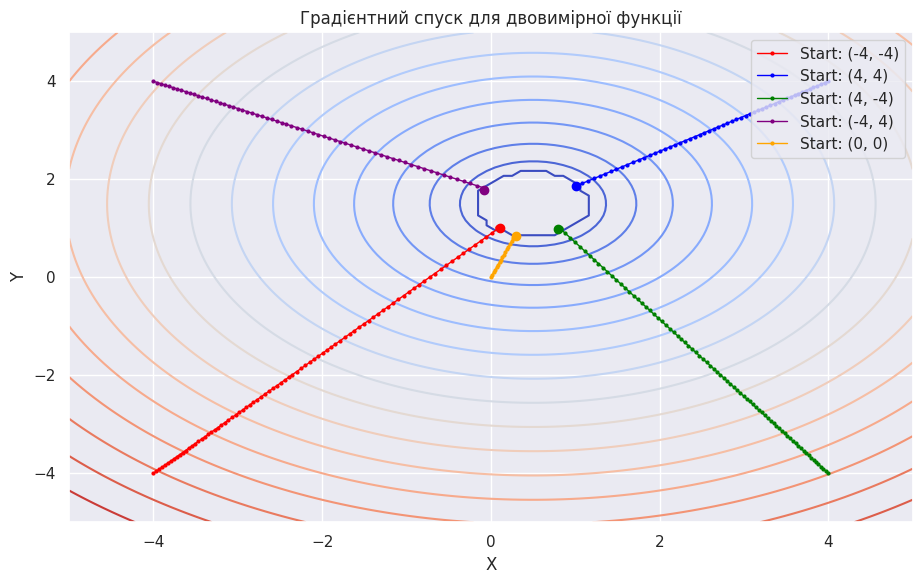

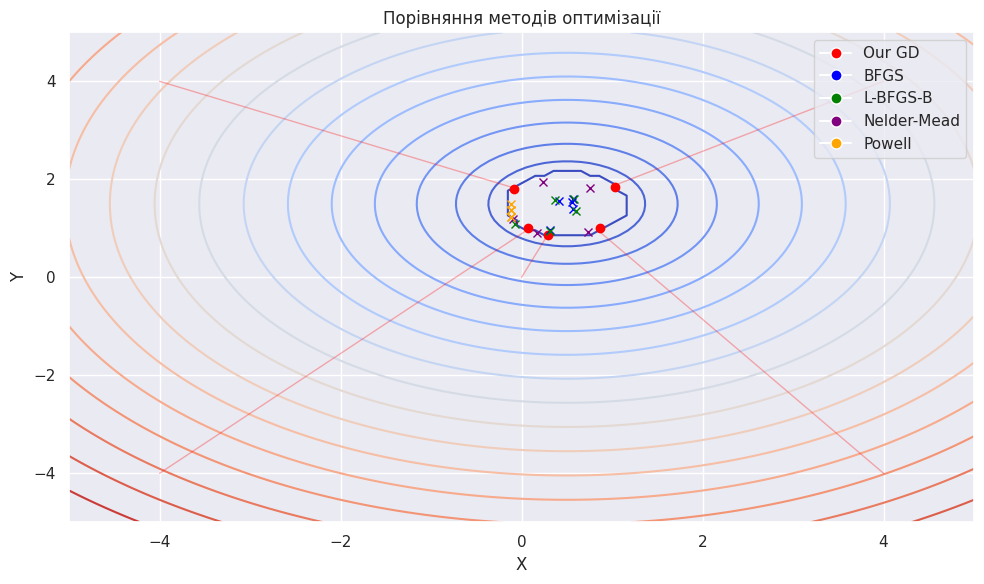

In [86]:
def scipy_objective(params):
    x, y = params
    return objective_function(x, y, c1, c2)

def compare_with_library(c1=1, c2=1):
    start_points = [(-4, -4), (4, 4), (4, -4), (-4, 4), (0, 0)]
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.linspace(-5, 5, 100)
    y = np.linspace(-5, 5, 100)
    X, Y = np.meshgrid(x, y)
    
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = objective_function(X[i, j], Y[i, j], c1, c2)
    
    contour = ax.contour(X, Y, Z, 20, cmap=cm.coolwarm)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Порівняння методів оптимізації')
    
    colors = {
        'Our GD': 'red',
        'BFGS': 'blue',
        'L-BFGS-B': 'green',
        'Nelder-Mead': 'purple',
        'Powell': 'orange'
    }
    
    method_results = {}
    
    for start_point in start_points:
        start_x, start_y = start_point
        
        min_x, min_y, path = gradient_descent(
            start_x, start_y,
            learning_rate=0.05,
            max_iterations=2000,
            eps=1e-8,
            c1=c1, c2=c2
        )
        
        path_x = [p[0] for p in path]
        path_y = [p[1] for p in path]
        ax.plot(path_x, path_y, '-', color=colors['Our GD'], linewidth=1, alpha=0.3)
        ax.plot(min_x, min_y, 'o', color=colors['Our GD'], markersize=6)
        
        method_name = 'Our GD'
        if method_name not in method_results:
            method_results[method_name] = []
        method_results[method_name].append((round(min_x, 4), round(min_y, 4)))
        
        methods = ['BFGS', 'L-BFGS-B', 'Nelder-Mead', 'Powell']
        
        for method in methods:
            result_scipy = optimize.minimize(
                scipy_objective, 
                np.array(start_point),
                method=method,
                tol=1e-8
            )
            
            end_point = tuple(result_scipy.x)
            end_x, end_y = end_point
            
            ax.plot(end_x, end_y, 'x', color=colors[method], markersize=6)
            
            if method not in method_results:
                method_results[method] = []
            method_results[method].append((round(end_x, 4), round(end_y, 4)))
    
    for method, points in method_results.items():
        print(f"{method}:")
        for i, point in enumerate(points):
            formatted_point = tuple(float(coord) for coord in point)
            start_point = start_points[i]
            print(f"Початок {start_point}: Мінімум функції знаходиться приблизно в точці {formatted_point}")
    
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, label=method, markersize=8) for method, color in colors.items()]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    return fig, method_results 

c1, c2 = 1, 1
    
print("c1 =", c1, ", c2 =", c2)
print("Власна функція")
plt_gd = plot_function_and_path(c1, c2)
fig_gd = plt.gcf()
print("\nScipy функції")
fig_compare, results = compare_with_library(c1, c2)
plt.figure(fig_compare.number)
plt.show()